In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
## performance: per seed performance
## lats_performance: avg over seed performance at the end of training
## last_performance_unnormalized: same as last_performance but without normalization
## max_performance: average over seeds (how?) max performance achieved during training (presumably)

# 1. Normalization

In [4]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(
    lambda g: (g["performance"] - g["_seed_avg"].min()) / (g["_seed_avg"].max() - g["_seed_avg"].min() + 1e-8)
)
data.drop(columns=["_seed_avg"], inplace=True)

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_62249/355322313.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(


# 1b) Filter Bad environments

In [5]:
# remove trash environments because they kill the cross-environment ranking later
bad_envs = ["cc_mountain_car", "minigrid_unlock"]
data = data[~data["env_name"].isin(bad_envs)]

# 2. Metrics

In [6]:
from scipy.stats import rankdata

In [7]:
kruskal_wallis_results = {}

for algo in data["algorithm"].unique():
    algo_data = data[data["algorithm"] == algo]

    kruskal_wallis_results[algo] = {}
    
    for env in data["env_name"].unique():
        env_algo_data = algo_data[algo_data["env_name"] == env]
        
        grouped = env_algo_data.groupby('config_id')['performance'].apply(list)

        # Find the maximum number of seeds for padding
        max_seeds = grouped.apply(len).max()

        # Pad each list to the same length (e.g., with np.nan)
        perf_matrix = np.array([
            performances + [np.nan] * (max_seeds - len(performances))
            for performances in grouped
        ])

        # calculate rank matrix
        flat = perf_matrix.flatten()
        mask = ~np.isnan(flat)
        ranks = np.full(flat.shape, np.nan)

        # Rank only the valid (non-NaN) entries
        # average does take the average rank of all ties
        ranks[mask] = rankdata(flat[mask], method='average')

        # Reshape back to the original matrix shape
        rank_matrix = ranks.reshape(perf_matrix.shape)

        # calculate H statistic on this
        N = np.prod(perf_matrix.shape)  # Total number of observations
        
        if N == 0:
            continue  # Skip if there are no observations
        
        S = perf_matrix.shape[-1] # Number of seeds (columns)

        H = (12 / (N * (N + 1) * S)) * np.sum(np.sum(rank_matrix, axis=-1) ** 2, axis=0) - 3 * (N + 1)

        # normalize
        eps_squared = H / (N - 1)

        kruskal_wallis_results[algo][env] = {
            "H": H,
            "eps_squared": eps_squared
        }

In [8]:
kruskal_wallis_results_df = pd.DataFrame([
    {
        "algorithm": algo,
        "env_name": env,
        "H": results["H"],
        "eps_squared": results["eps_squared"]
    }
    for algo, envs in kruskal_wallis_results.items()
    for env, results in envs.items()
])


plot_df = kruskal_wallis_results_df.groupby("algorithm").agg(
    mean_H=("H", "mean"),
    std_h=("H", "std"),
    mean_eps_squared=("eps_squared", "mean"),
    std_eps_squared=("eps_squared", "std")
).reset_index()

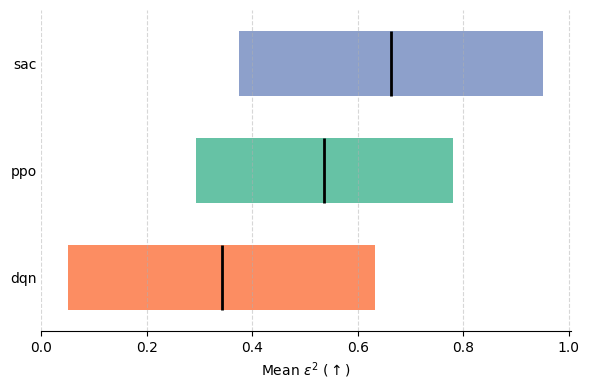

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4))
palette = sns.color_palette("Set2")
col_map = {"ppo": palette[0], "dqn": palette[1], "sac": palette[2]}

y = np.arange(len(plot_df))
height = 0.6
for i, row in enumerate(plot_df.itertuples(index=False)):
    left = row.mean_eps_squared - row.std_eps_squared
    width = row.std_eps_squared * 2
    rect = plt.Rectangle((left, i - height/2), width, height,
                         facecolor=col_map[row.algorithm], linewidth=1)
    ax.add_patch(rect)
    ax.vlines(row.mean_eps_squared, i - height/2, i + height/2, color="black", linewidth=2)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["algorithm"])
ax.set_xlabel(r"Mean $\epsilon^2$ ($\uparrow$)")
ax.set_xlim(0, plot_df["mean_eps_squared"].max() + plot_df["std_eps_squared"].max() + 0.05)
ax.set_ylim(-0.5, len(plot_df) - 0.5)

# style
ax.grid(axis="x", linestyle="--", alpha=0.5, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

# plt.title("Average $\epsilon^2$ per Algorithm")
plt.tight_layout()

In [10]:
kruskal_wallis_results_df = pd.DataFrame([
    {
        "algorithm": algo,
        "env_name": env,
        "H": results["H"],
        "eps_squared": results["eps_squared"]
    }
    for algo, envs in kruskal_wallis_results.items()
    for env, results in envs.items()
])

## use 95% CI instead std
plot_df = kruskal_wallis_results_df.groupby("algorithm").agg(
    mean_H=("H", "mean"),
    lower_H=("H", lambda x: np.percentile(x, 2.5)),
    upper_H=("H", lambda x: np.percentile(x, 97.5)),
    mean_eps_squared=("eps_squared", "mean"),
    lower_eps_squared=("eps_squared", lambda x: np.percentile(x, 0.5)),
    upper_eps_squared=("eps_squared", lambda x: np.percentile(x, 99.5))
).reset_index()

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_62249/3169369639.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_62249/3169369639.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


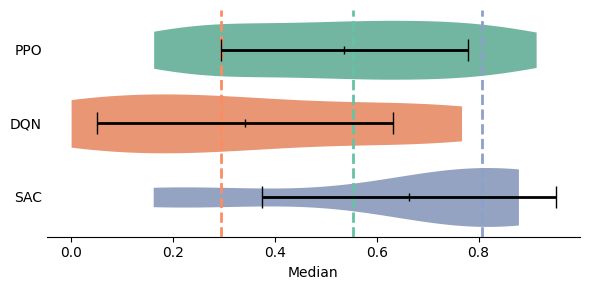

In [11]:
# Prepare data
algo_order = ["ppo", "dqn", "sac"]
palette = sns.color_palette("Set2")
col_map = {"ppo": palette[0], "dqn": palette[1], "sac": palette[2]}

fig, ax = plt.subplots(figsize=(6, 3))

# Violin plot for densities
sns.violinplot(
    data=kruskal_wallis_results_df,
    y="algorithm",
    x="eps_squared",
    order=algo_order,
    palette=col_map,
    ax=ax,
    cut=0,
    inner=None,
    linewidth=0,
    scale="width"
)

# Add horizontal error bars for mean ± std
for i, algo in enumerate(algo_order):
    vals = kruskal_wallis_results_df[kruskal_wallis_results_df["algorithm"] == algo]["eps_squared"]
    mean = vals.mean()
    std = vals.std()
    median = vals.median()
    ax.errorbar(mean, i, xerr=std, fmt='|', color="black", capsize=8, lw=2, zorder=10)
    # Add dashed line for median
    ax.axvline(median, color=col_map[algo], linestyle="--", lw=2, zorder=5)

ax.set_yticks(range(len(algo_order)))
ax.set_yticklabels([a.upper() for a in algo_order])
ax.set_xlabel(r"Median")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()

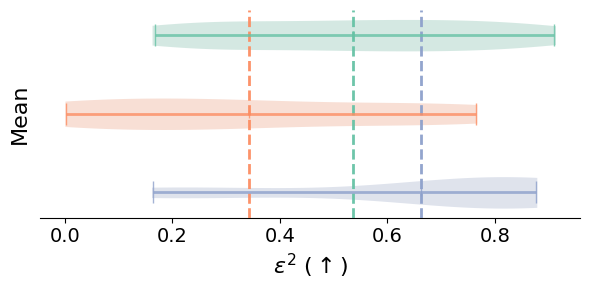

In [22]:
algo_order = ["ppo", "dqn", "sac"]
palette = sns.color_palette("Set2")
col_map = {"ppo": palette[0], "dqn": palette[1], "sac": palette[2]}

fig, ax = plt.subplots(figsize=(6, 3))

# Violin plot for densities
sns.violinplot(
    data=kruskal_wallis_results_df,
    y="algorithm",
    x="eps_squared",
    order=algo_order,
    palette=col_map,
    hue="algorithm",
    ax=ax,
    cut=0,
    inner=None,
    linewidth=0,
    width=0.4,
    density_norm='width',
    alpha=0.3,
    legend=False
)

for i, algo in enumerate(algo_order):
    row = plot_df[plot_df["algorithm"] == algo].iloc[0]
    mean = row["mean_eps_squared"]
    lower = row["lower_eps_squared"]
    upper = row["upper_eps_squared"]
    color = col_map[algo]
    # Error bar for 95% CI
    ax.errorbar(
        mean, i,
        xerr=[[mean - lower], [upper - mean]],
        fmt='|', color=color, alpha=0.8, capsize=8, lw=2, zorder=10
    )
    # Add dashed line for mean
    ax.axvline(mean, color=color, linestyle="--", lw=2, zorder=5, alpha=0.95)

ax.set_yticks(range(len(algo_order)))
# ax.set_xticks(fontsize=14)
# set the fontsize of x ticks to 14
ax.tick_params(axis='x', labelsize=14)
# ax.set_yticklabels([a.upper() for a in algo_order])
ax.set_yticklabels([])
ax.set_xlabel(r"$\epsilon^2$ ($\uparrow$)", fontsize=16)
ax.set_ylabel("Mean", fontsize=16)
# ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
# plt.savefig
plt.savefig("_figures/KruskalWallis.pdf", bbox_inches='tight')
plt.show()